# Проект 12 спринта: предсказание вероятности клика AdTech платформы Advandex

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 13 июня 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/sprint_12_project_advandex
___

## Описание задачи

Построить модель бинарной классификации для AdTech‑платформы Advandex, которая предсказывает вероятность клика (CTR) на рекламное объявление, провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.

Некорректные прогнозы несут прямые финансовые риски для платформы: если модель систематически завышает CTR (например, предсказывает 20 % при реальных 5 %), это приведёт к перерасходу бюджета рекламодателей, потере их доверия и неэффективным победам в аукционах. Напротив, заниженные оценки (5 % вместо реальных 20 %) заставят платформу проигрывать аукционы за перспективные показы — и терять потенциальный доход.

Конечная цель — создать точную и достоверную модель, в которой предсказанный показатель CTR максимально близко отражает реальную вероятность клика: если модель выдаёт 20 %, то в среднем клик должен происходить в 20 случаях из 100. Такая калибровка критически важна для бизнес‑модели Advandex, поскольку достоверность предсказаний напрямую влияет на эффективность аукционов и финансовые результаты платформы.
___

## Выбор метрик

Для оценки модели в этом проекте будут использованы три ключевые метрики:

- **PR-AUC** — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы, но при этом оно критически важно для бизнеса. Поэтому метрика PR-AUC идеально подойдёт. Она игнорирует дисбаланс классов и позволяет оценить, насколько хорошо модель находит именно целевые действия — клики.
- **Log Loss** позволит оценить точность предсказанных вероятностей. Это важно, чтобы оптимизировать ставки на аукционах, где от достоверности вероятностей напрямую зависит эффективность расходов рекламодателей.
- **Оценка Бриера** измеряет и точность, и калибровку модели, то есть общее соответствие прогнозов реальным результатам. Для платформы это имеет прямое финансовое значение, так как ошибки в прогнозах приводят либо к переплатам, либо к упущенной выгоде.

При необходимости используйте дополнительные метрики. Они могут помочь в спорных ситуациях:

- Для детального анализа калибровки пригодятся метрики **ECE** и **MCE**. Они оценивают, насколько хорошо откалиброваны предсказанные вероятности по разным диапазонам.
- Вспомогательные метрики точности:
  - **Precision** — точность предсказания кликов.
  - **Recall** — полнота охвата реальных кликов.
  - **F1-score** — балансирует точность и полноту.
___


## Описание данных

#### Идентификаторы и временные метки:

- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

#### Характеристики рекламной площадки (Site):

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

#### Характеристики рекламируемого приложения (App):

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

#### Характеристики устройства и соединения пользователя:

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

#### Характеристики рекламного баннера и аукциона:

- `C1` — анонимизированный признак, характеризующий контекст показа;
- `banner_pos` — позиция баннера на веб-странице;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

#### Машинно-сгенерированные признаки (ML Features):

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

#### Целевая переменная:

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.
___


# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.
___

In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

# Предобрабока данных
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from category_encoders import  LeaveOneOutEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Метрики
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, average_precision_score, classification_report

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import joblib
import os
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

path = os.getcwd()
RANDOM_SEED = 555

In [2]:
# Подготавливаем функции визуализации данных

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):
    """
    Строит столбчатую диаграмму с метками значений и процентов.

    Параметры:
    -----------
    data : array-like или pd.Series
        Вектор данных для построения диаграммы.
    figsize : tuple, optional
        Размер фигуры (ширина, высота) в дюймах. По умолчанию (12, 6).
    xlabel : str, optional
        Подпись оси X (по умолчанию 'Категория').
    ylabel : str, optional
        Подпись оси Y (по умолчанию 'Количество').
    title : str, optional
        Заголовок графика (по умолчанию 'Столбчатая диаграмма').
    top_n : int, optional
        Количество категорий для отображения (самые частые). По умолчанию 5.
    """
    # Преобразуем данные в Series, если это ещё не сделано
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    # Подсчёт значений и отбор топ‑N категорий
    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    # Создаём контейнер графика matplotlib и задаём его размер
    plt.figure(figsize=figsize)

    # Строим столбчатую диаграмму
    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    # Добавляем сетку графика
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Добавление меток на столбики (абсолютные значения)
    for i, v in enumerate(value_counts):
        # Смещение по Y пропорционально общему количеству для лучшей читаемости
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    # Добавление меток процентов
    for i, v in enumerate(value_counts_normalized):
        # Позиция по Y — половина высоты столбца (чтобы надпись была по центру)
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    # Улучшаем отображение, чтобы избежать обрезания элементов
    plt.tight_layout()

    # Выводим график
    plt.show()


In [3]:
# Загружаем датасет

df_init = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [4]:
# Знакомимся с данными
df_init.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [5]:
df_init.shape

(50000, 34)

In [6]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [7]:
# Создадим функцию оптимизации типов данных датафрейма
def optimize_dataframe(df):
    dataset_cols_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    dataset_cols_int = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

    for col in dataset_cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in dataset_cols_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

In [8]:
# Оптимизируем типы данных датафрейма и сохраним в новый рабочий датафрейм df_work. Первоначальный df_init оставим для отслеживания изменений. 

df_work = optimize_dataframe(df_init)

## Комментарий по итогам подготовки среды и загрузки данных

- Подготовлено виртуальное окружение, состав библиотек проекта зафиксирован в файле `requirements.txt`.
- Импортированы все необходимые библиотеки и настроены системные параметры, а также параметры отображения графиков и датафреймов. Зафиксирована константа `RANDOM_SEED = 555`.
- Данные загружены успешно. Датасет содержит 34 атрибута и 50 000 записей.
- На основе начального датафрейма создан новый с оптимизированной структурой типов данных. Начальный датафрем оставлен для сравнения и отслеживания изменений по ходу проекта.
___

## 2. Исследовательский анализ данных (EDA)

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.
___

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

In [9]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

#### Объём данных

- **Количество объектов (строк):** 50 000 (RangeIndex от 0 до 49 999).
- **Количество признаков (столбцов):** 34.
- **Пропуски:** Не обнаружены (во всех 34 колонках указано `50000 non-null`).

#### Типы данных

В датасете представлены следующие основные типы данных:

- **Числовые:**
  - `float32` (7 колонок): `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`.
  - `float64` (1 колонка): `id`.
  - `int16` (7 колонок): `C1`, `C14`–`C17`, `C19`.
  - `int32` (2 колонки): `hour`, `C20`.
  - `int8` (6 колонок): `click`, `banner_pos`, `device_type`, `device_conn_type`, `C18`.

- **Категориальные / Строковые:**
  - `str` (11 колонок): `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_id`, `device_ip`, `device_model`, `ml_feature_2`, `ml_feature_7`.

#### Общее описание и контекст

Датасет описывает **показы рекламных баннеров** и содержит информацию, позволяющую связать контекст показа с поведением пользователя (кликом или его отсутствием).

**Что известно о рекламе (контекст показа):**
- **Площадка:** `site_id`, `site_domain`, `site_category` — где именно был показан баннер (сайт, его домен и тематика).
- **Продукт/Приложение:** `app_id`, `app_domain`, `app_category` — что рекламировалось (идентификатор, домен и категория приложения).
- **Позиция и контекст:** `banner_pos` (позиция на странице), `C1` (контекст показа), анонимизированные признаки `C14`–`C21` (дополнительные параметры аукциона/баннера).

**Что известно о пользователе:**
- **Устройство:** `device_model`, `device_type` (смартфон, ПК и т. д.), `device_conn_type` (тип соединения: Wi-Fi, 3G и др.).
- **Идентификаторы:** `device_id`, `device_ip` — для отслеживания конкретного устройства/пользователя.

**Целевая переменная:**
- `click` (тип `int8`) — бинарный признак, указывающий, был ли совершён клик (1 — клик был, 0 — не было). Это наша **целевая метка** для задачи бинарной классификации.

**Дополнительные признаки:**
- **Машинно-сгенерированные (`ml_feature_*`):** Представляют собой результат предварительной обработки. Включают как числовые (вероятно, агрегированные статистики), так и категориальные признаки.

**Краткий вывод:**  
Датасет сбалансирован по полноте (нет пропусков), содержит контекст как о рекламе, так и о пользователе, и готов к исследовательскому анализу и дальнейшей предобработке.
___


#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

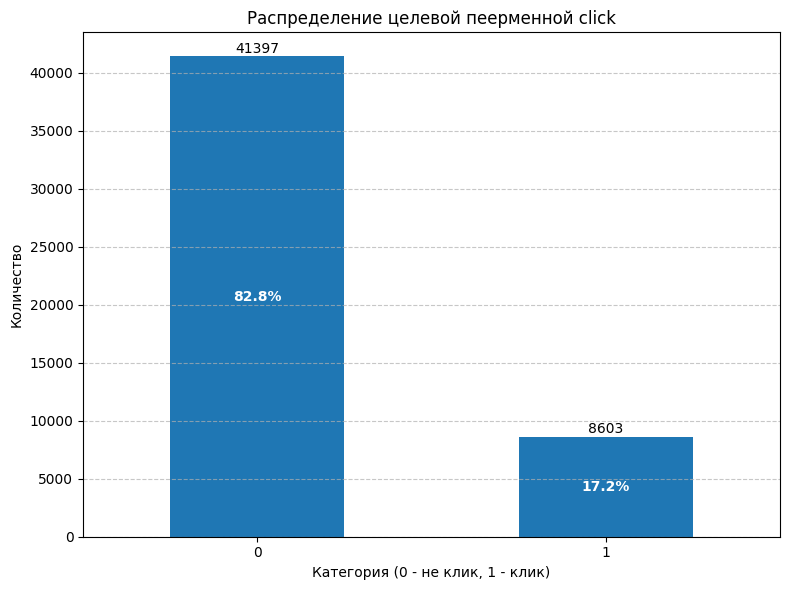

In [10]:
plot_bar_chart(data=df_work['click'], figsize=(8, 6), xlabel='Категория (0 - не клик, 1 - клик)', ylabel='Количество', title='Распределение целевой пеерменной click')

#### Целевая переменная `click`

1. **Распределение классов**  
   Целевая переменная `click` имеет два значения:
   - `0` (не клик) — **41 397** записей (82.8%);
   - `1` (клик) — **8 603** записи (17.2%).

2. **Наличие дисбаланса**  
   В датасете **явно выражен дисбаланс классов**.  
   Класс «не клик» (`0`) значительно преобладает над классом «клик» (`1`) в соотношении примерно **5 к 1**.  

3. **Выбор метрик**  
   Дисбаланс классов обосновывает использование в качестве основных метрик модели:
- **PR-AUC** (Precision-Recall AUC) - особенно информативен при сильном дисбалансе.
- **Precision (точность)** — доля верно предсказанных кликов среди всех предсказаний «клик».
- **Recall (полнота)** — доля реальных кликов, которые модель смогла найти.
- **F1-score** — гармоническое среднее между Precision и Recall (хорошо подходит для несбалансированных данных).
___


#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

In [11]:
df_work.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146790,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319133,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [12]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

In [13]:
# Напишем простую функцию удаления ненужных колонок
def drop_unneccesary_columns(df, cols_2_drop):
    return df.drop(columns=cols_2_drop)

In [14]:
# Распределеям признаки по категориям и делаем проверку контрольной суммы. Должно быть 34 признака.
target = ['click']
columns_to_drop = ['id', 'device_id', 'device_ip', 'device_model', 'device_conn_type']
categorical_features = [item for item in df_work.select_dtypes(include=['str']).columns.tolist() if item not in columns_to_drop + target] + ['C1', 'banner_pos', 'device_type', 'hour']
numerical_features = sorted([item for item in df_work.select_dtypes(include=['float64', 'float32', 'int8', 'int16', 'int32', 'int64']).columns.tolist() + ['C20'] if item not in columns_to_drop + ['id'] + categorical_features + target])
print(f'Проверка числа признаков. В датасете всего {df_work.shape[1]} признака. Отобрано по категориям {len(target + columns_to_drop + categorical_features + numerical_features)} признака.')

Проверка числа признаков. В датасете всего 34 признака. Отобрано по категориям 34 признака.


In [15]:
df_work = df_work.drop(columns=columns_to_drop)

In [16]:
df_work[numerical_features].describe()

,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_10,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,18826.648680,318.86640,59.692480,2109.781020,1.428100,227.703800,53173.383240,83.685180,-0.002445,0.020226,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361
std,4983.064178,20.56153,46.720842,612.963141,1.327413,351.592108,49960.181871,70.539513,1.000280,0.303309,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034
min,375.000000,120.00000,20.000000,112.000000,0.000000,33.000000,-1.000000,13.000000,-4.631262,-1.287965,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526
25%,16920.000000,320.00000,50.000000,1823.000000,0.000000,35.000000,-1.000000,23.000000,-0.677784,-0.182386,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077
50%,20346.000000,320.00000,50.000000,2323.000000,2.000000,39.000000,100049.000000,61.000000,-0.003776,0.018930,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985
75%,21916.000000,320.00000,50.000000,2526.000000,3.000000,171.000000,100094.000000,108.000000,0.673534,0.224080,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152
max,24043.000000,1024.00000,1024.000000,2757.000000,3.000000,1839.000000,100248.000000,255.000000,3.793828,1.202300,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786


In [17]:
df_work[categorical_features].astype('str').describe()

,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7,C1,banner_pos,device_type,hour
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,1160,1013,18,976,67,22,5,3,7,7,4,240
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,E,Y,1005,0,1,14102209
freq,18011,18645,20457,31989,33763,32388,10112,17081,45835,35883,46031,547


#### Выводы по анализу признаков

В датасете 34 атрибута. Из них 1 целевая переменная `click`.

Принято решение **удалить как несущественные** идентификаторы показа баннера, а также признаки описывающие устройство пользователя:
- `id` - уникальный идентификатор записи о показе баннера;
- `device_id` - идентификатор браузера или устройства;
- `device_ip` - IP-адрес устройства;
- `device_model` - модель устройства;
- `device_conn_type` - тип сетевого соединения устройства
Все это фоновые признаки, которые не оказывают влияния на принятие пользователем решения о клике. Исключение составляет `device_type` - тип устройства смартфон, планшет или ПК, так ка предположительно диагональ устройства может влиять на расположение баннера, что в свою очередь, может быть существенным для принятия решения о клике.

К **категориальным признакам** относятся все признаки типа 'str', но также и целочисленные `C1`, `banner_pos`, `device_type` и `hour`. Критерием отбора было то, что номера здесь описывают скорее какую-то качественную,нежели количественную, характеристику и имеют очень малое число уникальных значений по сравнению с общим числом записей в датасете. Немного особняком здесь стоит признак `hour`. Но его название вводит в заблуждение, так как это не час, в который был показан баннер, а дата плюс час в формате 'YYMMDDHH'. Если для дальнейшего анализа мы принимаем в расчет именно час показа, признак нужно будет преобразовать оставив только последние две цифры 'HH'.  
('site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'ml_feature_2', 'ml_feature_7', 'C1', 'banner_pos', 'device_type', 'hour')

В **числовым признакам** были отнесены все колонки с типом 'float', а также целочисленные, содержащие именно количественные характеристики.  
('C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_10', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9')

___

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

___

___

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.